In [1]:
import matplotlib.pyplot as plt
import numpy as np

from datetime import datetime, timedelta

In [2]:
# Ensures reproducibility of random numbers
rng = np.random.default_rng(1234)

# timedelta(i) adds "i" days to the 1st of January of 2019
date = [datetime(2019, 1, 1) + timedelta(i) for i in range(100)]
temperature = np.arange(100) ** 2.5 / 10000 + rng.uniform(size=100) 
price = np.arange(120, 20, -1) ** 1.5 / 10 + rng.uniform(size=100)

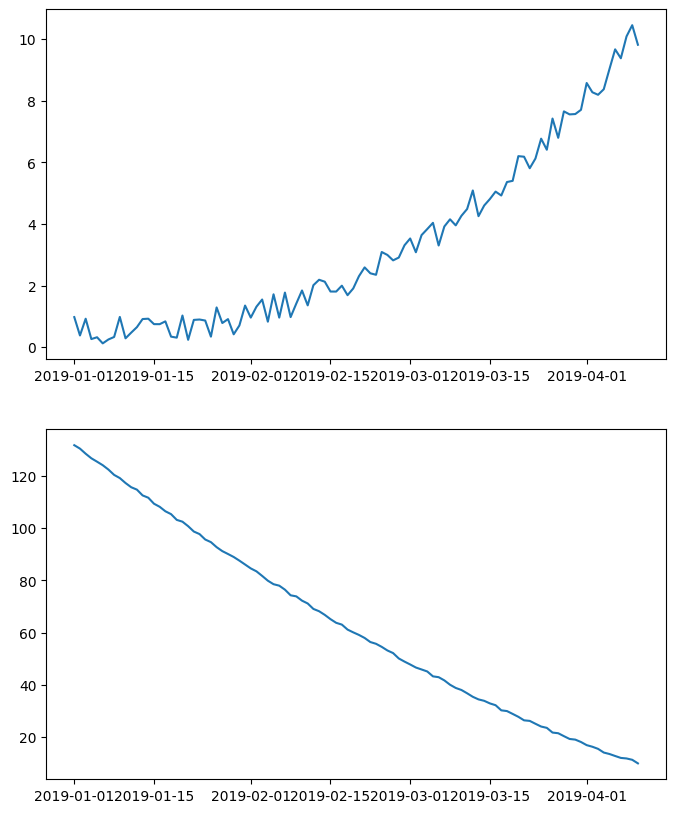

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

axes[0].plot(date, temperature)
axes[1].plot(date, price);

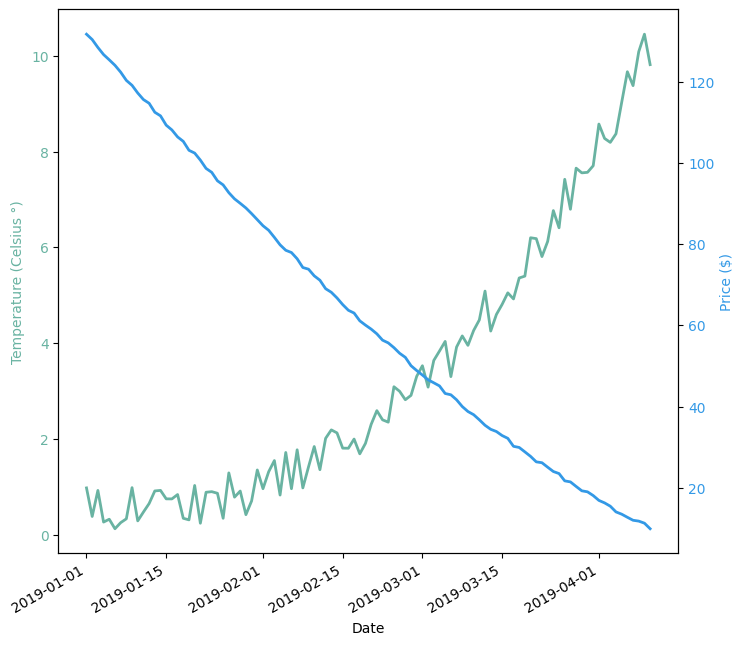

In [ ]:
COLOR_TEMPERATURE = "#69b3a2"
COLOR_PRICE = "#3399e6"

fig, ax1 = plt.subplots(figsize=(8, 8))
ax2 = ax1.twinx()

ax1.plot(date, temperature, color=COLOR_TEMPERATURE, lw=2)
ax1.set_xlabel("Date")
ax1.set_ylabel("Temperature (Celsius °)", color=COLOR_TEMPERATURE, fontsize=10)
ax1.tick_params(axis="y", labelcolor=COLOR_TEMPERATURE)


ax2.plot(date, price, color=COLOR_PRICE, lw=2)
ax2.set_ylabel("Price ($)", color=COLOR_PRICE, fontsize=10)
ax2.tick_params(axis="y", labelcolor=COLOR_PRICE)

# fig.suptitle("Temperature down, price up", fontsize=20)
fig.autofmt_xdate()

plt.show()

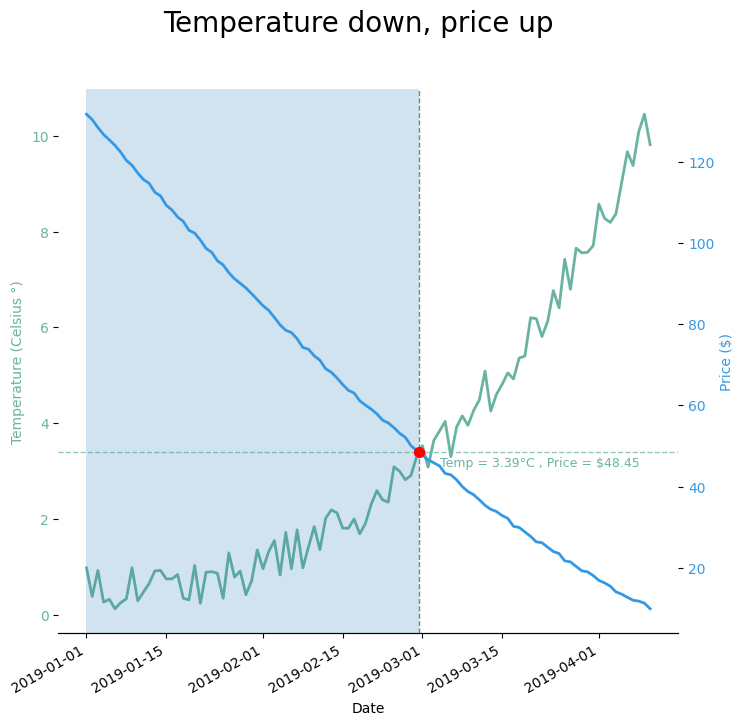

In [47]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

COLOR_TEMPERATURE = "#69b3a2"
COLOR_PRICE = "#3399e6"

fig, ax1 = plt.subplots(figsize=(8, 8))
ax2 = ax1.twinx()

# plot lines
ax1.plot(date, temperature, color=COLOR_TEMPERATURE, lw=2)
ax2.plot(date, price, color=COLOR_PRICE, lw=2)

ax1.set_xlabel("Date")
ax1.set_ylabel("Temperature (Celsius °)", color=COLOR_TEMPERATURE, fontsize=10)
ax1.tick_params(axis="y", labelcolor=COLOR_TEMPERATURE)

ax2.set_ylabel("Price ($)", color=COLOR_PRICE, fontsize=10)
ax2.tick_params(axis="y", labelcolor=COLOR_PRICE)

fig.autofmt_xdate()

# -----------------------------
# Find first visual intersection
# -----------------------------
x_num = mdates.date2num(date)

# transform both curves into display coordinates
temp_disp = ax1.transData.transform(np.column_stack([x_num, temperature]))
price_disp = ax2.transData.transform(np.column_stack([x_num, price]))

# difference in screen y-position
diff = temp_disp[:, 1] - price_disp[:, 1]

# find first sign change
cross_idx = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]


if len(cross_idx) > 0:
    i = cross_idx[0]

    # linear interpolation factor
    t = diff[i] / (diff[i] - diff[i + 1])
    # interpolated x
    x_cross = x_num[i] + t * (x_num[i + 1] - x_num[i])

    # interpolated values from each series y = mx + c
    temp_cross = temperature[i] + t * (temperature[i + 1] - temperature[i])
    price_cross = price[i] + t * (price[i + 1] - price[i])

    x_cross_date = mdates.num2date(x_cross)

    # 1) dot at intersection point
    ax2.scatter(x_cross_date, price_cross, color="red", s=50, zorder=5)

    # 2) dashed guide lines
    ax1.axvline(x_cross_date, color="gray", linestyle="--", lw=1)
    ax1.axhline(temp_cross, color=COLOR_TEMPERATURE, linestyle="--", lw=1, alpha=0.7)

    # annotations
    ax1.annotate(
        f"Temp = {temp_cross:.2f}°C , Price = ${price_cross:.2f}",
        xy=(x_cross_date, temp_cross),
        xytext=(15, -10),
        textcoords="offset points",
        color=COLOR_TEMPERATURE,
        fontsize=9
    )

    ax2.axvspan(mdates.num2date(x_num[0]), x_cross_date, alpha=0.2)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)

fig.suptitle("Temperature down, price up", fontsize=20)
plt.show()


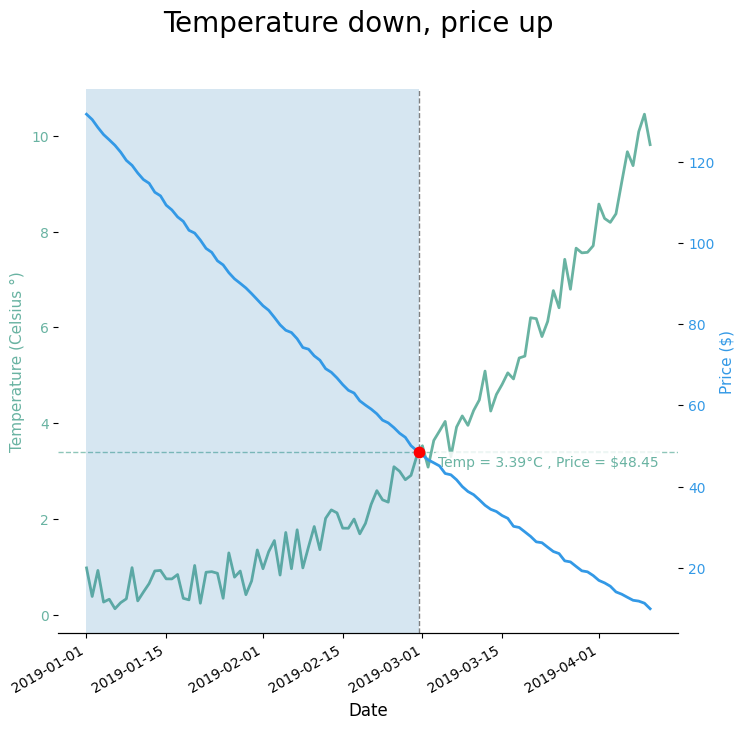

In [48]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np


# =========================
# Style settings
# =========================
COLOR_TEMPERATURE = "#69b3a2"
COLOR_PRICE = "#3399e6"
COLOR_INTERSECTION = "red"
COLOR_GUIDE = "gray"
SHADE_ALPHA = 0.18


def find_first_visual_intersection(ax1, ax2, x_dates, y1, y2):
    x_num = mdates.date2num(x_dates)

    # Convert both curves into screen/display coordinates
    pts1_display = ax1.transData.transform(np.column_stack([x_num, y1]))
    pts2_display = ax2.transData.transform(np.column_stack([x_num, y2]))

    # Compare vertical screen position
    diff = pts1_display[:, 1] - pts2_display[:, 1]

    # Find the first interval where the sign changes
    cross_idx = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]
    if len(cross_idx) == 0:
        return None

    i = cross_idx[0]

    # Linear interpolation to estimate the crossing location
    t = diff[i] / (diff[i] - diff[i + 1])

    x_cross_num = x_num[i] + t * (x_num[i + 1] - x_num[i])
    y1_cross = y1[i] + t * (y1[i + 1] - y1[i])
    y2_cross = y2[i] + t * (y2[i + 1] - y2[i])

    return {
        "x_num": x_cross_num,
        "x_date": mdates.num2date(x_cross_num),
        "y1": y1_cross,
        "y2": y2_cross,
        "index": i,
    }


def style_axes(ax1, ax2):
    """Apply a cleaner style to the twin-axis chart."""
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_visible(False)

    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)


def annotate_intersection(ax1, ax2, cross_info):
    """Draw marker, guide lines, annotation, and shaded region."""
    x_cross = cross_info["x_date"]
    temp_cross = cross_info["y1"]
    price_cross = cross_info["y2"]

    # Dot at the intersection location
    ax2.scatter(x_cross, price_cross, color=COLOR_INTERSECTION, s=55, zorder=6)

    # Guide lines
    ax1.axvline(x_cross, color=COLOR_GUIDE, linestyle="--", lw=1)
    ax1.axhline(temp_cross, color=COLOR_TEMPERATURE, linestyle="--", lw=1, alpha=0.75)

    # Annotation
    ax1.annotate(
        f"Temp = {temp_cross:.2f}°C , Price = ${price_cross:.2f}",
        xy=(x_cross, temp_cross),
        xytext=(14, -10),
        textcoords="offset points",
        color=COLOR_TEMPERATURE,
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85),
    )

    # Shade the region before the first intersection
    x_start = ax1.get_lines()[0].get_xdata()[0]
    ax2.axvspan(x_start, x_cross, alpha=SHADE_ALPHA)


def plot_temperature_price_story(date, temperature, price):
    """
    Plot a storytelling chart with:
    - twin y-axes
    - first visual intersection
    - annotation and guide lines
    - minimal styling
    """
    fig, ax1 = plt.subplots(figsize=(8, 8))
    ax2 = ax1.twinx()

    # Plot lines
    ax1.plot(date, temperature, color=COLOR_TEMPERATURE, lw=2)
    ax2.plot(date, price, color=COLOR_PRICE, lw=2)

    # Labels
    ax1.set_xlabel("Date", fontsize=12)
    ax1.set_ylabel("Temperature (Celsius °)", color=COLOR_TEMPERATURE, fontsize=11)
    ax2.set_ylabel("Price ($)", color=COLOR_PRICE, fontsize=11)

    ax1.tick_params(axis="y", labelcolor=COLOR_TEMPERATURE)
    ax2.tick_params(axis="y", labelcolor=COLOR_PRICE)

    # Force draw so transforms are correct before intersection calculation
    fig.canvas.draw()

    # Find and annotate the first visual intersection
    cross_info = find_first_visual_intersection(ax1, ax2, date, temperature, price)
    if cross_info is not None:
        annotate_intersection(ax1, ax2, cross_info)

    # Clean style
    style_axes(ax1, ax2)

    # Title
    fig.suptitle("Temperature down, price up", fontsize=20)

    # Format dates
    fig.autofmt_xdate()

    plt.show()


# =========================
# Run
# =========================
plot_temperature_price_story(date, temperature, price)

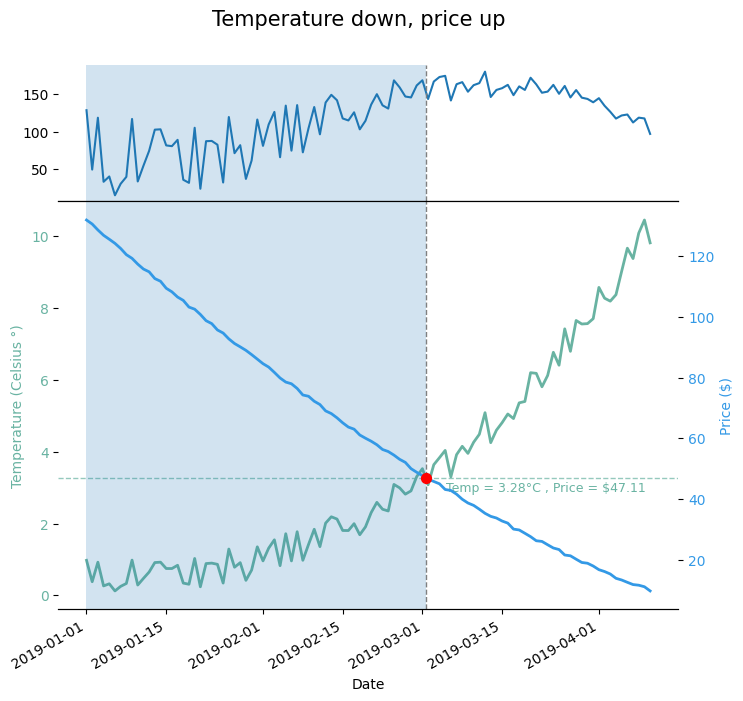

In [75]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

COLOR_TEMPERATURE = "#69b3a2"
COLOR_PRICE = "#3399e6"

add_on = temperature * price
fig, ax1 = plt.subplots(2, 1, sharex=True, figsize=(8, 8), gridspec_kw={'height_ratios': [1, 3]})
fig.subplots_adjust(hspace=0)
ax2 = ax1[1].twinx()


ax1[0].plot(date, add_on)

# plot lines
ax1[1].plot(date, temperature, color=COLOR_TEMPERATURE, lw=2)
ax2.plot(date, price, color=COLOR_PRICE, lw=2)

ax1[1].set_xlabel("Date")
ax1[1].set_ylabel("Temperature (Celsius °)", color=COLOR_TEMPERATURE, fontsize=10)
ax1[1].tick_params(axis="y", labelcolor=COLOR_TEMPERATURE)

ax2.set_ylabel("Price ($)", color=COLOR_PRICE, fontsize=10)
ax2.tick_params(axis="y", labelcolor=COLOR_PRICE)

fig.autofmt_xdate()

# -----------------------------
# Find first visual intersection
# -----------------------------
x_num = mdates.date2num(date)

# transform both curves into display coordinates
temp_disp = ax1[1].transData.transform(np.column_stack([x_num, temperature]))
price_disp = ax2.transData.transform(np.column_stack([x_num, price]))

# difference in screen y-position
diff = temp_disp[:, 1] - price_disp[:, 1]

# find first sign change
cross_idx = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]


if len(cross_idx) > 0:
    i = cross_idx[1]

    # linear interpolation factor
    t = diff[i] / (diff[i] - diff[i + 1])
    # interpolated x
    x_cross = x_num[i] + t * (x_num[i + 1] - x_num[i])

    # interpolated values from each series y = mx + c
    temp_cross = temperature[i] + t * (temperature[i + 1] - temperature[i])
    price_cross = price[i] + t * (price[i + 1] - price[i])

    x_cross_date = mdates.num2date(x_cross)

    # 1) dot at intersection point
    ax2.scatter(x_cross_date, price_cross, color="red", s=50, zorder=5)

    # 2) dashed guide lines
    ax1[1].axvline(x_cross_date, color="gray", linestyle="--", lw=1)
    ax1[1].axhline(temp_cross, color=COLOR_TEMPERATURE, linestyle="--", lw=1, alpha=0.7)

    # annotations
    ax1[1].annotate(
        f"Temp = {temp_cross:.2f}°C , Price = ${price_cross:.2f}",
        xy=(x_cross_date, temp_cross),
        xytext=(15, -10),
        textcoords="offset points",
        color=COLOR_TEMPERATURE,
        fontsize=9
    )

    ax2.axvspan(mdates.num2date(x_num[0]), x_cross_date, alpha=0.2)

ax1[0].axvline(x_cross_date, color="gray", linestyle="--", lw=1)
ax1[0].axvspan(mdates.num2date(x_num[0]), x_cross_date, alpha=0.2)


ax1[1].spines["right"].set_visible(False)
ax1[1].spines["left"].set_visible(False)

ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)

ax1[0].spines["top"].set_visible(False)
ax1[0].spines["right"].set_visible(False)
ax1[0].spines["left"].set_visible(False)


fig.suptitle("Temperature down, price up", fontsize=15, y=0.95)
plt.show()


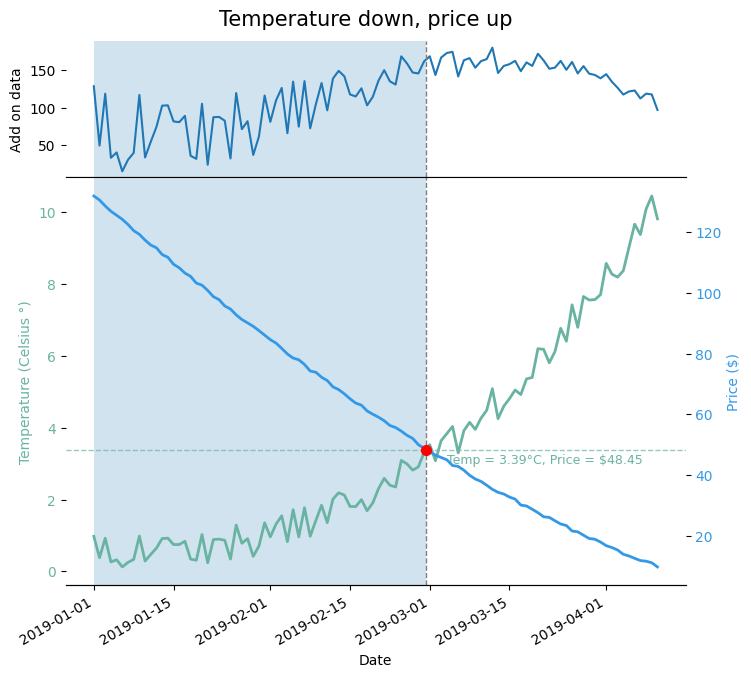

In [82]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

COLOR_TEMPERATURE = "#69b3a2"
COLOR_PRICE = "#3399e6"

# extra line for top subplot
add_on = temperature * price

# create 2 rows, shared x-axis
fig, ax = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(8, 8),
    gridspec_kw={"height_ratios": [1, 3]}
)
fig.subplots_adjust(hspace=0)

# second y-axis on bottom plot
ax_right = ax[1].twinx()

# -------------------------
# Plot lines
# -------------------------
ax[0].plot(date, add_on, color="#1f77b4", lw=1.5)

ax[1].plot(date, temperature, color=COLOR_TEMPERATURE, lw=2)
ax_right.plot(date, price, color=COLOR_PRICE, lw=2)

# labels
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Temperature (Celsius °)", color=COLOR_TEMPERATURE, fontsize=10)
ax[0].set_ylabel("Add on data", fontsize=10)
ax_right.set_ylabel("Price ($)", color=COLOR_PRICE, fontsize=10)

ax[1].tick_params(axis="y", labelcolor=COLOR_TEMPERATURE)
ax_right.tick_params(axis="y", labelcolor=COLOR_PRICE)

fig.autofmt_xdate()

# -------------------------
# Find visual intersection
# -------------------------
x_num = mdates.date2num(date)

temp_display = ax[1].transData.transform(np.column_stack([x_num, temperature]))
price_display = ax_right.transData.transform(np.column_stack([x_num, price]))

diff = temp_display[:, 1] - price_display[:, 1]
cross_idx = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]

if len(cross_idx) > 0:
    i = cross_idx[0]   # first intersection

    # linear interpolation
    t = diff[i] / (diff[i] - diff[i + 1])

    x_cross = x_num[i] + t * (x_num[i + 1] - x_num[i])
    temp_cross = temperature[i] + t * (temperature[i + 1] - temperature[i])
    price_cross = price[i] + t * (price[i + 1] - price[i])

    x_cross_date = mdates.num2date(x_cross)

    # red point
    ax_right.scatter(x_cross_date, price_cross, color="red", s=50, zorder=5)

    # dashed guide lines
    ax[1].axvline(x_cross_date, color="gray", linestyle="--", lw=1)
    ax[1].axhline(temp_cross, color=COLOR_TEMPERATURE, linestyle="--", lw=1, alpha=0.7)

    # text annotation
    ax[1].annotate(
        f"Temp = {temp_cross:.2f}°C, Price = ${price_cross:.2f}",
        xy=(x_cross_date, temp_cross),
        xytext=(15, -10),
        textcoords="offset points",
        color=COLOR_TEMPERATURE,
        fontsize=9
    )

    # highlight region before intersection
    ax[1].axvspan(date[0], x_cross_date, alpha=0.2)
    ax[0].axvline(x_cross_date, color="gray", linestyle="--", lw=1)
    ax[0].axvspan(date[0], x_cross_date, alpha=0.2)

# -------------------------
# Remove frame
# -------------------------
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[0].spines["left"].set_visible(False)

ax[1].spines["right"].set_visible(False)
ax[1].spines["left"].set_visible(False)

ax_right.spines["top"].set_visible(False)
ax_right.spines["left"].set_visible(False)
ax_right.spines["right"].set_visible(False)

fig.suptitle("Temperature down, price up", fontsize=15, y=0.92)
plt.show()